In [1]:
# imports
from src.helpers.gromacs import *
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
import nglview as nv

Helper functions loaded.


In [2]:
# SETUP
warnings.filterwarnings("ignore", category=DeprecationWarning)

DATA_DIR = 'results/'

# Set protein name
protein='9GBG'

# Set all files
pdb=f'../{protein}.pdb'
box=f'boxed.gro'



os.chdir(DATA_DIR)
print(f"Working directory set to: {os.getcwd()}")

Working directory set to: /Users/jaimeduarteniemen/Documents/Bioinformatics/dissertation/gromacs/gold_standards/predicted/9GBG/results


In [3]:
# Visualise original structure
view = nv.show_structure_file(pdb)
view

NGLWidget()

In [4]:
import MDAnalysis as mda
import nglview as nv



u1 = mda.Universe(f"psychrophilic/{box}", "psychrophilic/md_center.xtc")
u2 = mda.Universe(f"mesophilic/{box}", "mesophilic/md_center.xtc")
u3 = mda.Universe(f"thermophilic/{box}", "thermophilic/md_center.xtc")

view = nv.NGLWidget()

c0=view.add_trajectory(u1) # psychrophilic
c1=view.add_trajectory(u2) # mesophilic
c2=view.add_trajectory(u3) # thermophilic

# Clear and style each component separately
# IMPORTANT: clear per component, not globally ambiguous
view.clear_representations(component=0)
view.clear_representations(component=1)
view.clear_representations(component=2)


view.add_cartoon("protein", component=0, color="blue")
view.add_cartoon("protein", component=1, color="green")
view.add_cartoon("protein", component=2, color="red")

#offset each protein so they dont overlap
c0.set_position([50, 100, 0])
c1.set_position([0, 100, 0])
c2.set_position([-50, 100, 0])


view.center()
view

NGLWidget(max_frame=2000)

# Energy Minimisation - Potential Energy


Psychrophilic
Initial Epot: 1,265,693,440 kJ/mol
Final   Epot: -429,021 kJ/mol
Change:       -1,266,122,461 kJ/mol

Mesophilic
Initial Epot: 1,265,693,568 kJ/mol
Final   Epot: -428,770 kJ/mol
Change:       -1,266,122,338 kJ/mol

Thermophilic
Initial Epot: 1,265,694,720 kJ/mol
Final   Epot: -428,216 kJ/mol
Change:       -1,266,122,936 kJ/mol


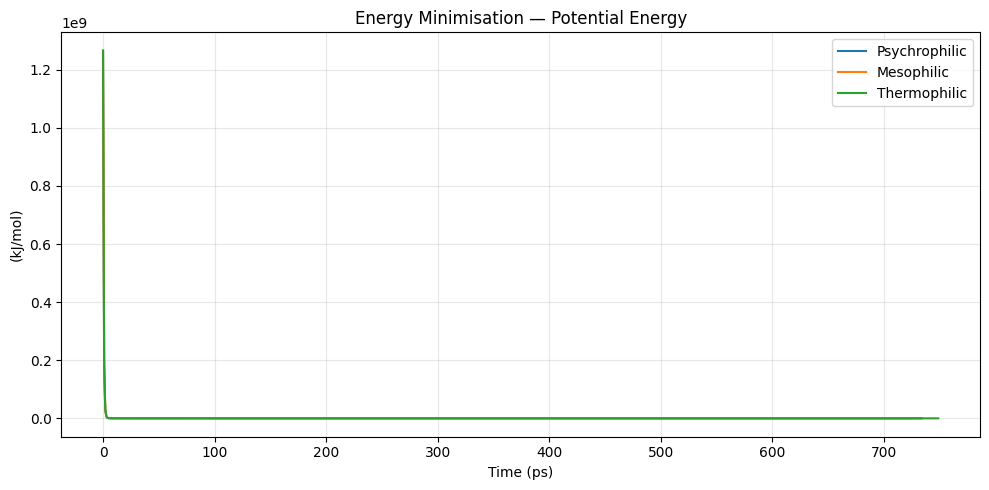

In [6]:
import matplotlib.pyplot as plt

files = {
    "Psychrophilic": "psychrophilic/potential.xvg",
    "Mesophilic": "mesophilic/potential.xvg",
    "Thermophilic": "thermophilic/potential.xvg",
}

plt.figure(figsize=(10, 5))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    epot = d["columns"][:, 0]

    plt.plot(x, epot, label=label)

    print(f"\n{label}")
    print(f"Initial Epot: {epot[0]:,.0f} kJ/mol")
    print(f"Final   Epot: {epot[-1]:,.0f} kJ/mol")
    print(f"Change:       {epot[-1] - epot[0]:,.0f} kJ/mol")

plt.title("Energy Minimisation — Potential Energy")
plt.xlabel(d["xlabel"])
plt.ylabel(d["ylabel"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# NVT Equilibration - Temperature



Psychrophilic
Mean temperature: 288.1 K
Std deviation:    1.5 K

Mesophilic
Mean temperature: 310.7 K
Std deviation:    1.9 K

Thermophilic
Mean temperature: 337.8 K
Std deviation:    1.9 K


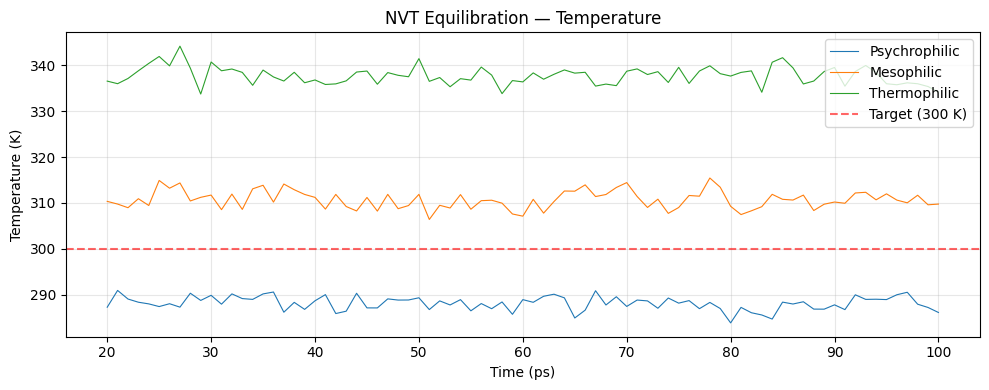

In [7]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": "psychrophilic/temperature.xvg",
    "Mesophilic": "mesophilic/temperature.xvg",
    "Thermophilic": "thermophilic/temperature.xvg",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    temp = d["columns"][:, 0]

    ax.plot(x, temp, linewidth=0.8, label=label)

    print(f"\n{label}")
    print(f"Mean temperature: {np.mean(temp):.1f} K")
    print(f"Std deviation:    {np.std(temp):.1f} K")

# Target temperature line (consistent formatting with your style)
ax.axhline(
    y=300,
    color="red",
    linestyle="--",
    alpha=0.6,
    label="Target (300 K)"
)

ax.set_title("NVT Equilibration — Temperature")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Temperature (K)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# NPT Equilibration - Pressure


Psychrophilic
Mean pressure:  -21.3 bar
Std deviation:  230.6 bar
RMSE from 1 bar:231.7 bar

Mesophilic
Mean pressure:  -18.8 bar
Std deviation:  270.5 bar
RMSE from 1 bar:271.2 bar

Thermophilic
Mean pressure:  -7.0 bar
Std deviation:  238.7 bar
RMSE from 1 bar:238.8 bar


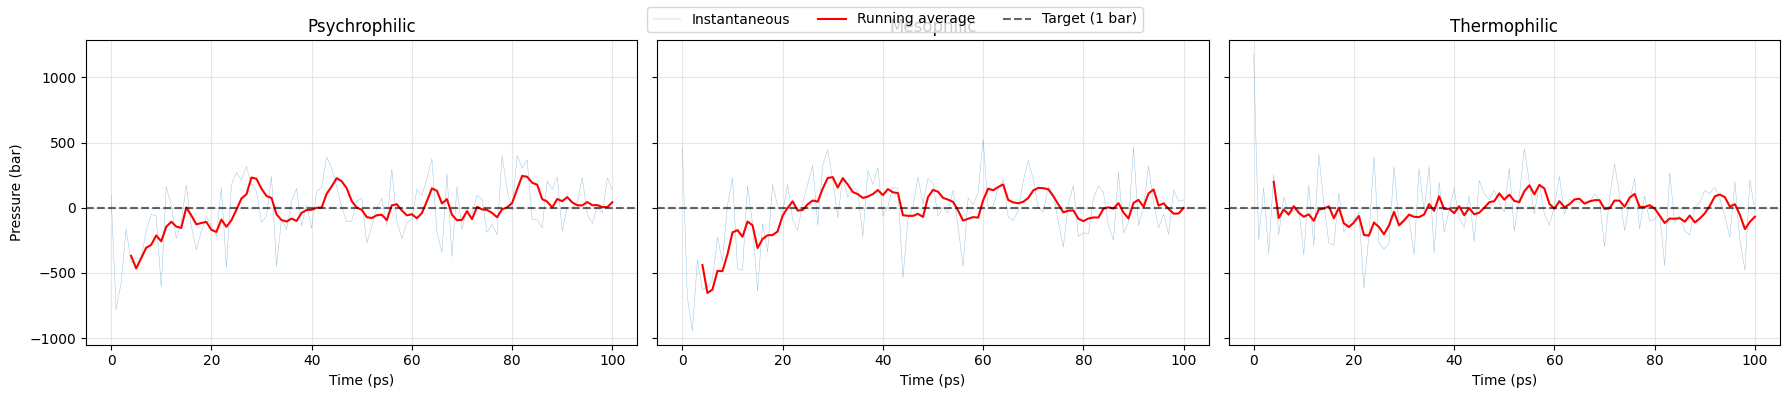

In [8]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": "psychrophilic/pressure.xvg",
    "Mesophilic": "mesophilic/pressure.xvg",
    "Thermophilic": "thermophilic/pressure.xvg",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (label, file) in zip(axes, files.items()):
    d = parse_xvg(file)

    x = d["time"]
    pressure = d["columns"][:, 0]

    ax.plot(x, pressure, linewidth=0.3, alpha=0.5, label="Instantaneous")

    window = max(1, len(pressure) // 20)
    running_avg = np.convolve(pressure, np.ones(window)/window, mode="valid")

    ax.plot(
        x[window-1:],
        running_avg,
        linewidth=1.5,
        color="red",
        label="Running average"
    )

    ax.axhline(
        y=1,
        color="black",
        linestyle="--",
        alpha=0.6,
        label="Target (1 bar)"
    )

    ax.set_title(label)
    ax.set_xlabel(d["xlabel"])
    ax.grid(True, alpha=0.3)

    print(f"\n{label}")
    print(f"Mean pressure:  {np.mean(pressure):.1f} bar")
    print(f"Std deviation:  {np.std(pressure):.1f} bar")
    print(f"RMSE from 1 bar:{np.sqrt(np.mean((pressure - 1)**2)):.1f} bar")

axes[0].set_ylabel("Pressure (bar)")

# single shared legend (cleaner than repeating 3 times)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout()
plt.show()

# NPT Equilibration - Density


Psychrophilic
Mean density:  1046.7 kg/m³
Std deviation: 9.8 kg/m³

Mesophilic
Mean density:  1030.5 kg/m³
Std deviation: 7.3 kg/m³

Thermophilic
Mean density:  1006.0 kg/m³
Std deviation: 4.2 kg/m³


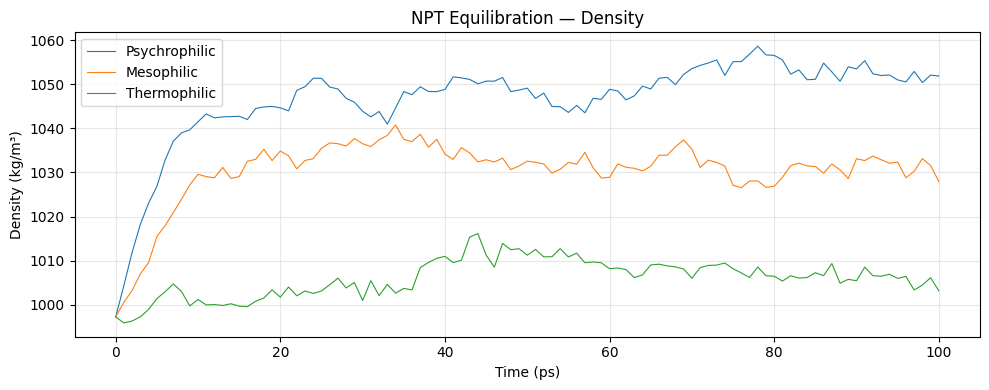

In [9]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": "psychrophilic/density.xvg",
    "Mesophilic": "mesophilic/density.xvg",
    "Thermophilic": "thermophilic/density.xvg",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    density = d["columns"][:, 0]

    ax.plot(x, density, linewidth=0.8, label=label)

    print(f"\n{label}")
    print(f"Mean density:  {np.mean(density):.1f} kg/m³")
    print(f"Std deviation: {np.std(density):.1f} kg/m³")

ax.set_title("NPT Equilibration — Density")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Density (kg/m³)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Minimum Image distance


Psychrophilic
Minimum distance observed: 1.245 nm
Mean distance:             1.938 nm

✓ OK: Minimum distance always exceeds 1.2 nm cutoff.

Mesophilic
Minimum distance observed: 1.052 nm
Mean distance:             1.734 nm

⚠️  WARNING: Distance dropped below 1.2 nm cutoff — periodic images may interact!
   Consider using a larger box (increase -d value in gmx editconf).

Thermophilic
Minimum distance observed: 1.498 nm
Mean distance:             2.034 nm

✓ OK: Minimum distance always exceeds 1.2 nm cutoff.


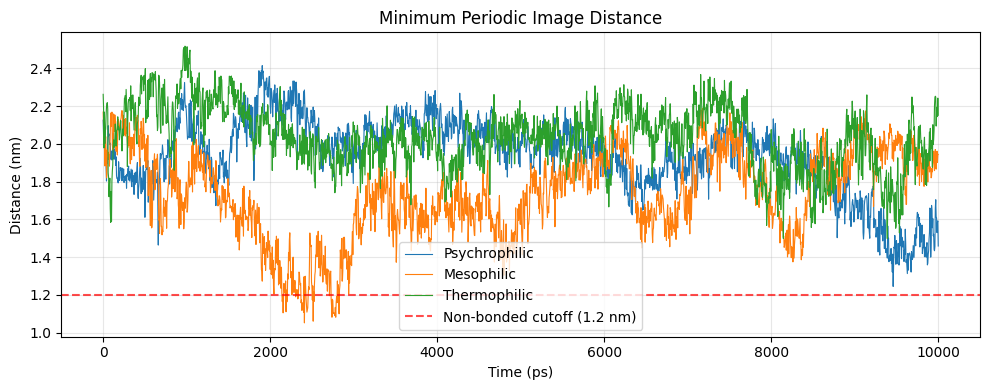

In [10]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": "psychrophilic/mindist.xvg",
    "Mesophilic": "mesophilic/mindist.xvg",
    "Thermophilic": "thermophilic/mindist.xvg",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    mindist = d["columns"][:, 0]

    ax.plot(x, mindist, linewidth=0.8, label=label)

    print(f"\n{label}")
    print(f"Minimum distance observed: {np.min(mindist):.3f} nm")
    print(f"Mean distance:             {np.mean(mindist):.3f} nm")

    if np.min(mindist) < 1.2:
        print("\n⚠️  WARNING: Distance dropped below 1.2 nm cutoff — periodic images may interact!")
        print("   Consider using a larger box (increase -d value in gmx editconf).")
    else:
        print("\n✓ OK: Minimum distance always exceeds 1.2 nm cutoff.")

# cutoff line
ax.axhline(
    y=1.2,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Non-bonded cutoff (1.2 nm)"
)

ax.set_title("Minimum Periodic Image Distance")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Distance (nm)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# RMSD - Structural Stability


Psychrophilic
Final RMSD:         0.316 nm (3.2 Å)
Mean RMSD:          0.306 nm (3.1 Å)
Mean (last 25%):    0.316 nm (3.2 Å)

Mesophilic
Final RMSD:         0.500 nm (5.0 Å)
Mean RMSD:          0.431 nm (4.3 Å)
Mean (last 25%):    0.496 nm (5.0 Å)

Thermophilic
Final RMSD:         0.458 nm (4.6 Å)
Mean RMSD:          0.395 nm (4.0 Å)
Mean (last 25%):    0.437 nm (4.4 Å)


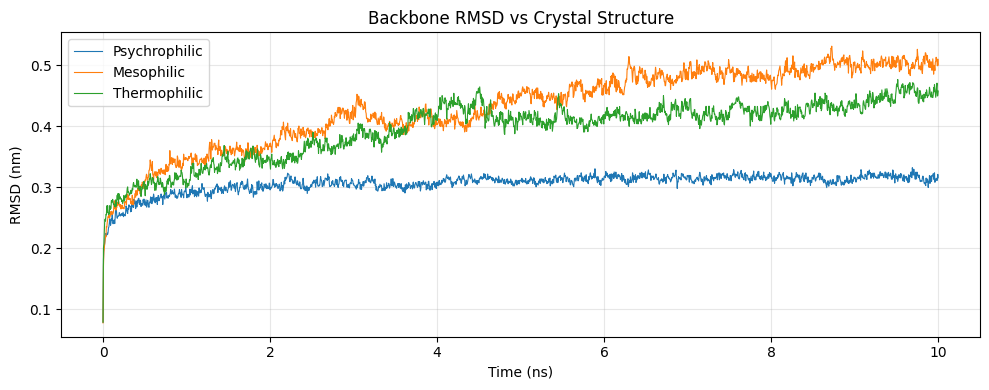

In [11]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": "psychrophilic/rmsd.xvg",
    "Mesophilic": "mesophilic/rmsd.xvg",
    "Thermophilic": "thermophilic/rmsd.xvg",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    rmsd = d["columns"][:, 0]

    ax.plot(x, rmsd, linewidth=0.8, label=label)

    print(f"\n{label}")
    print(f"Final RMSD:         {rmsd[-1]:.3f} nm ({rmsd[-1]*10:.1f} Å)")
    print(f"Mean RMSD:          {np.mean(rmsd):.3f} nm ({np.mean(rmsd)*10:.1f} Å)")
    print(f"Mean (last 25%):    {np.mean(rmsd[len(rmsd)*3//4:]):.3f} nm "
          f"({np.mean(rmsd[len(rmsd)*3//4:])*10:.1f} Å)")

ax.set_title("Backbone RMSD vs Crystal Structure")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("RMSD (nm)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Radius of Gyration


Psychrophilic
Mean Rg:            1.928 nm
Std deviation:      0.006 nm
Mean Rg (last 25%): 1.930 nm

Mesophilic
Mean Rg:            1.955 nm
Std deviation:      0.021 nm
Mean Rg (last 25%): 1.977 nm

Thermophilic
Mean Rg:            1.933 nm
Std deviation:      0.010 nm
Mean Rg (last 25%): 1.939 nm


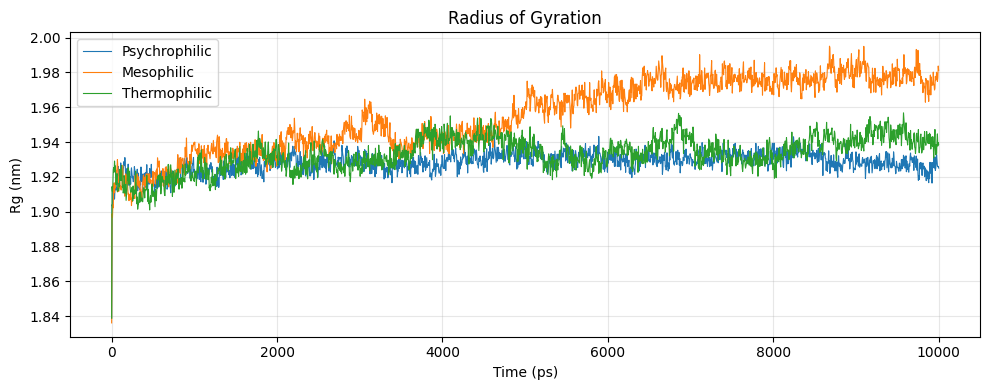

In [12]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": "psychrophilic/gyrate.xvg",
    "Mesophilic": "mesophilic/gyrate.xvg",
    "Thermophilic": "thermophilic/gyrate.xvg",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    rg = d["columns"][:, 0]

    ax.plot(x, rg, linewidth=0.8, label=label)

    print(f"\n{label}")
    print(f"Mean Rg:            {np.mean(rg):.3f} nm")
    print(f"Std deviation:      {np.std(rg):.3f} nm")
    print(f"Mean Rg (last 25%): {np.mean(rg[len(rg)*3//4:]):.3f} nm")

ax.set_title("Radius of Gyration")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Rg (nm)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()